# Interpretando odds ratio

**Tema:** Aprendizado Supervisionado › Regressão Logística

Este notebook constrói, passo a passo, a diferença entre "as chances
aumentam X%" e "a probabilidade aumenta X%" — a confusão mais comum ao
interpretar regressão logística — e mostra como a mesma mudança de odds
produz mudanças bem diferentes de probabilidade dependendo do ponto de
partida.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

rng = np.random.default_rng(6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("pronto")

pronto


## 1. Um modelo simples para trabalhar

In [2]:
n = 2000
n_atrasos = rng.integers(0, 6, n)
renda_mil = rng.lognormal(np.log(5), 0.5, n)

logit = -2.0 + 0.7 * n_atrasos - 0.15 * renda_mil
prob = 1 / (1 + np.exp(-logit))
inadimplente = (rng.random(n) < prob).astype(int)

X = np.column_stack([n_atrasos, renda_mil])
modelo = LogisticRegression().fit(X, inadimplente)

print(f"intercepto: {modelo.intercept_[0]:.4f}")
print(f"coeficientes: {modelo.coef_[0]}")
print(f"\nodds ratio (exp dos coeficientes): {np.exp(modelo.coef_[0])}")

intercepto: -1.7861
coeficientes: [ 0.67446949 -0.17593681]

odds ratio (exp dos coeficientes): [1.96299131 0.83867098]


## 2. "As chances aumentam X%" vs. "a probabilidade aumenta X%"

Vamos aumentar `n_atrasos` em 1 unidade a partir de três pontos de partida
diferentes, e comparar a mudança em ODDS com a mudança em PROBABILIDADE.

In [3]:
def prob_para_odds(p):
    return p / (1 - p)


coef_atrasos = modelo.coef_[0][0]
razao_odds = np.exp(coef_atrasos)
print(f"odds ratio de n_atrasos: {razao_odds:.4f}  "
      f"(cada atraso a mais MULTIPLICA as chances por este fator)")

pontos_partida = {"probabilidade baixa (0,05)": 0.05,
                  "probabilidade média (0,40)": 0.40,
                  "probabilidade alta (0,90)": 0.90}

print(f"\n{'ponto de partida':<28s} {'odds antes':>12s} {'odds depois':>13s} "
      f"{'prob antes':>12s} {'prob depois':>13s} {'Δ prob':>10s}")
print("-" * 92)
for nome, p0 in pontos_partida.items():
    odds0 = prob_para_odds(p0)
    odds1 = odds0 * razao_odds
    p1 = odds1 / (1 + odds1)
    print(f"{nome:<28s} {odds0:>12.4f} {odds1:>13.4f} {p0:>12.2%} {p1:>13.2%} "
          f"{p1-p0:>+10.2%}")

odds ratio de n_atrasos: 1.9630  (cada atraso a mais MULTIPLICA as chances por este fator)

ponto de partida               odds antes   odds depois   prob antes   prob depois     Δ prob
--------------------------------------------------------------------------------------------
probabilidade baixa (0,05)         0.0526        0.1033        5.00%         9.36%     +4.36%
probabilidade média (0,40)         0.6667        1.3087       40.00%        56.68%    +16.68%
probabilidade alta (0,90)          9.0000       17.6669       90.00%        94.64%     +4.64%


**A mesma razão de odds produz mudanças de probabilidade bem diferentes**
dependendo de onde você começa — grande no meio da escala (perto de 50%),
pequena nos extremos (perto de 0% ou 100%). "As chances aumentam 100%"
nunca significa "a probabilidade aumenta 100%" — e a diferença cresce
exatamente nos extremos, onde intuições ingênuas mais se enganam.

## 3. Visualizando a curva sigmoide e por que ela "achata" nos extremos

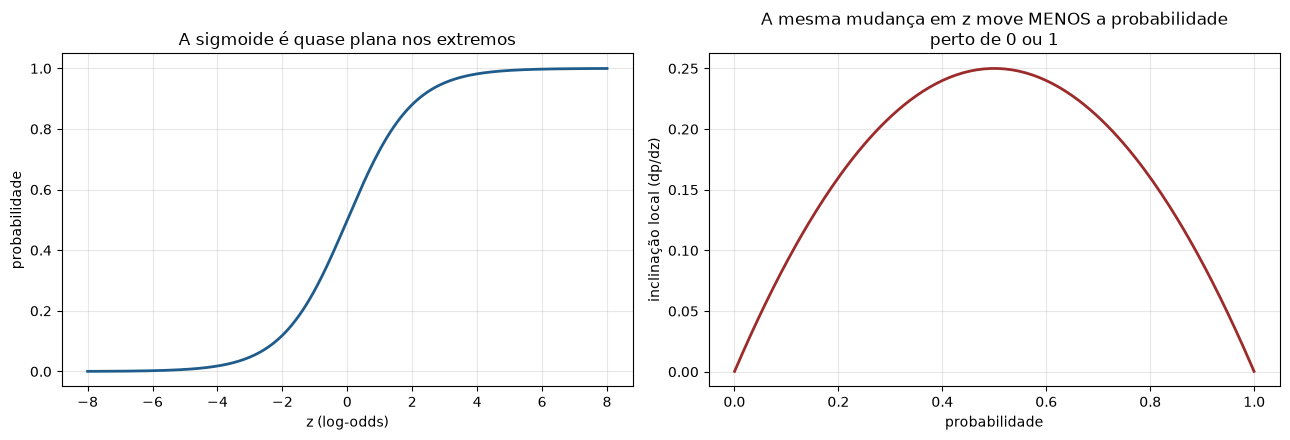

A inclinação da sigmoide é p(1-p), máxima em p=0.5 e mínima nos extremos.
É por isso que o MESMO aumento de odds (multiplicativo, constante) produz
uma mudança de probabilidade MENOR quando a probabilidade já é extrema.


In [4]:
z = np.linspace(-8, 8, 300)
p = 1 / (1 + np.exp(-z))
inclinacao = p * (1 - p)  # derivada da sigmoide

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(z, p, color=AZUL, lw=2)
axes[0].set_xlabel("z (log-odds)"); axes[0].set_ylabel("probabilidade")
axes[0].set_title("A sigmoide é quase plana nos extremos")

axes[1].plot(p, inclinacao, color=VERMELHO, lw=2)
axes[1].set_xlabel("probabilidade"); axes[1].set_ylabel("inclinação local (dp/dz)")
axes[1].set_title("A mesma mudança em z move MENOS a probabilidade\nperto de 0 ou 1")
plt.tight_layout(); plt.show()

print("A inclinação da sigmoide é p(1-p), máxima em p=0.5 e mínima nos extremos.")
print("É por isso que o MESMO aumento de odds (multiplicativo, constante) produz")
print("uma mudança de probabilidade MENOR quando a probabilidade já é extrema.")

## 4. Intervalo de confiança do odds ratio

O erro-padrão do coeficiente (via a matriz de informação de Fisher, a
versão logística da matriz de covariância do módulo 1) permite construir
um IC para o coeficiente e, exponenciando os limites, para o odds ratio.

In [5]:
from scipy import stats

# matriz de informação de Fisher observada: X^T W X, com W = diag(p(1-p))
X_com_intercepto = np.column_stack([np.ones(n), X])
p_ajustado = modelo.predict_proba(X)[:, 1]
W = np.diag(p_ajustado * (1 - p_ajustado))
info_fisher = X_com_intercepto.T @ W @ X_com_intercepto
cov_beta = np.linalg.inv(info_fisher)
erro_padrao = np.sqrt(np.diag(cov_beta))

coefs_completos = np.concatenate([modelo.intercept_, modelo.coef_[0]])
z_critico = stats.norm.ppf(0.975)

nomes = ["intercepto", "n_atrasos", "renda_mil"]
print(f"{'variável':<14s} {'coef':>9s} {'odds ratio':>12s} "
      f"{'IC 95% odds ratio':>24s}")
print("-" * 62)
for nome, coef, ep in zip(nomes, coefs_completos, erro_padrao):
    ic_inf = np.exp(coef - z_critico * ep)
    ic_sup = np.exp(coef + z_critico * ep)
    print(f"{nome:<14s} {coef:>9.4f} {np.exp(coef):>12.4f} "
          f"[{ic_inf:>8.4f}, {ic_sup:>8.4f}]")

variável            coef   odds ratio        IC 95% odds ratio
--------------------------------------------------------------
intercepto       -1.7861       0.1676 [  0.1224,   0.2295]
n_atrasos         0.6745       1.9630 [  1.8230,   2.1137]
renda_mil        -0.1759       0.8387 [  0.8042,   0.8746]


## O que levar deste notebook

- Odds ratio ($e^{\beta}$) mede um efeito **multiplicativo sobre as
  chances**, nunca um efeito direto sobre a probabilidade.
- A mesma razão de odds produz mudanças de probabilidade diferentes
  dependendo do ponto de partida — maiores perto de 50%, menores nos
  extremos, por causa da forma da sigmoide.
- Odds ratio, como qualquer estimativa, tem incerteza — reporte sempre com
  intervalo de confiança, exponenciando os limites do IC do coeficiente.

→ Próximo: **Caso real: scoring de crédito**, aplicando tudo isso a um
problema completo.